In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv(r"C:\Users\Neel Arora\OneDrive\Desktop\Advanced Machine Learning\Advanced Machine Learning\Ensemble Model\Boosting\Gradient Approach Boosting\CAT Boost\Income Prediction\adult.csv.zip")
df.drop_duplicates(inplace=True)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.shape

(48790, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        48790 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       48790 non-null  object
 7   relationship     48790 non-null  object
 8   race             48790 non-null  object
 9   gender           48790 non-null  object
 10  capital-gain     48790 non-null  int64 
 11  capital-loss     48790 non-null  int64 
 12  hours-per-week   48790 non-null  int64 
 13  native-country   48790 non-null  object
 14  income           48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [5]:
df.nunique()

age                   74
workclass              9
fnlwgt             28523
education             16
educational-num       16
marital-status         7
occupation            15
relationship           6
race                   5
gender                 2
capital-gain         123
capital-loss          99
hours-per-week        96
native-country        42
income                 2
dtype: int64

In [6]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [7]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})


In [8]:
x = df.drop('income', axis=1)
y = df['income']


In [9]:
cat_features = x.select_dtypes(include=['object']).columns
cat_features_idx = [x.columns.get_loc(col) for col in cat_features]


In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((39032, 14), (9758, 14), (39032,), (9758,))

In [12]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    class_weights=[1, 3],  
    cat_features=cat_features_idx,
    verbose=100
)

model.fit(x_train, y_train)


0:	total: 187ms	remaining: 1m 33s
100:	total: 6.44s	remaining: 25.4s
200:	total: 12.5s	remaining: 18.6s
300:	total: 18s	remaining: 11.9s
400:	total: 23.9s	remaining: 5.91s
499:	total: 29.2s	remaining: 0us


In [13]:
y_proba = model.predict_proba(x_test)[:,1]
y_pred = (y_proba > 0.4).astype(int)

In [14]:
auc = roc_auc_score(y_test, y_proba)
print("AUC Score:", auc)

AUC Score: 0.9270917254054034


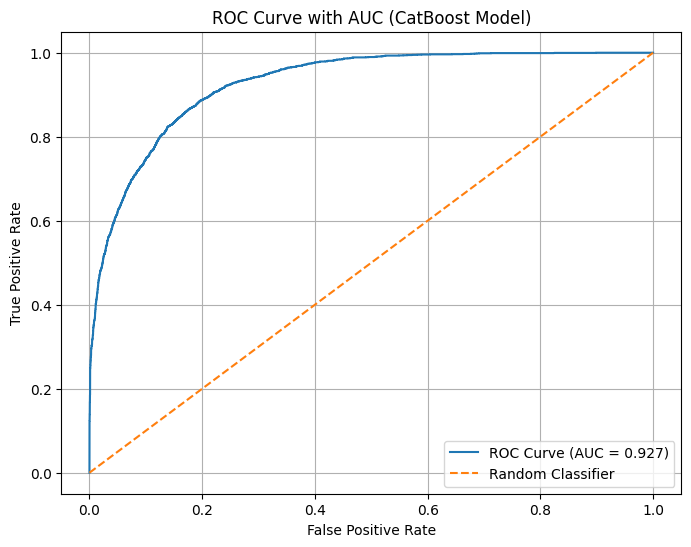

In [15]:
# Probabilities
y_proba = model.predict_proba(x_test)[:, 1]

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_proba)

# AUC Score
auc = roc_auc_score(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(8,6))

# ROC Line
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")

# Baseline Random Line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with AUC (CatBoost Model)")
plt.legend()
plt.grid()

plt.show()

In [16]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[5740 1682]
 [ 215 2121]]


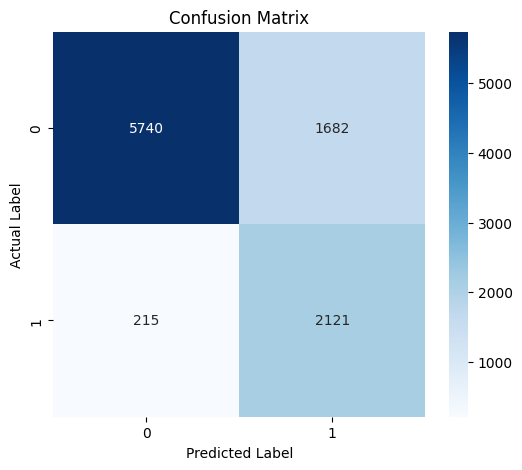

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [18]:
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.77      0.86      7422
           1       0.56      0.91      0.69      2336

    accuracy                           0.81      9758
   macro avg       0.76      0.84      0.77      9758
weighted avg       0.87      0.81      0.82      9758



In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8055954088952654


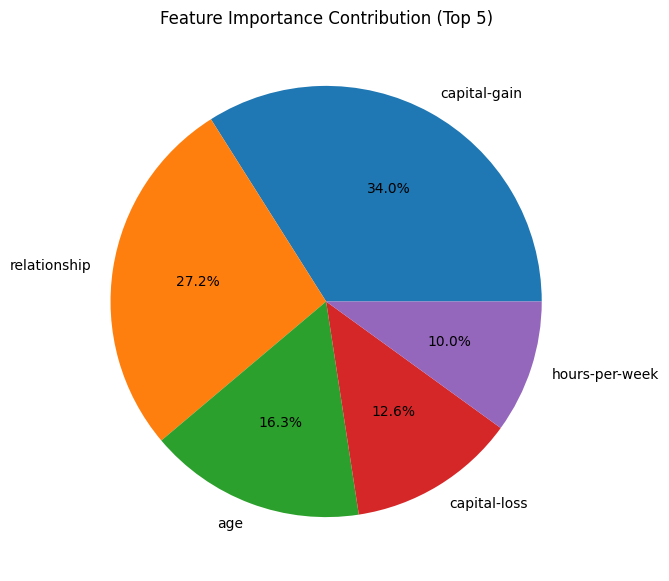

In [20]:
feat_imp = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

feat_imp = feat_imp.head(5)

plt.figure(figsize=(7,7))
plt.pie(feat_imp["Importance"],
        labels=feat_imp["Feature"],
        autopct="%1.1f%%")

plt.title("Feature Importance Contribution (Top 5)")
plt.show()
